In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parent
sys.path.insert(0, str(repo_root))

print("Repo root:", repo_root)

Repo root: C:\Users\llr\regime-filtered-momentum


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_ingest import load_ohlcv
from src.model_regime import generate_regime_probabilities, REGIME_ORDER
from src.signals import six_month_momentum_signal, regime_filtered_signal
from src.strategy import positions_from_signal
from src.backtest import run_backtest
from src.metrics import summarize_backtest
from src.config import CFG

Load SPY data

In [3]:
df = load_ohlcv()
df.head(), df.tail(), df.shape

(               Open     High      Low    Close    Volume
 Date                                                    
 2005-02-25  92.7949  93.8716  92.7097  93.6948  79289004
 2005-02-28  93.4735  93.5952  92.6083  93.0544  89985785
 2005-03-01  93.1845  93.7683  93.1845  93.5386  61658442
 2005-03-02  93.1749  94.0766  93.0735  93.4927  83253671
 2005-03-03  93.8716  94.0575  93.1203  93.5301  80491538,
               Open    High     Low   Close     Volume
 Date                                                 
 2026-03-06  673.41  676.11  669.76  672.38  100686951
 2026-03-09  666.39  679.92  662.39  678.27  102667711
 2026-03-10  677.72  683.36  674.76  677.18   81505315
 2026-03-11  677.58  680.08  673.34  676.33   68441672
 2026-03-12  671.16  671.65  665.87  666.06  108882246,
 (5293, 5))

In [4]:
regime_df = generate_regime_probabilities(df)
regime_df.head(), regime_df.shape

(               Open     High      Low    Close    Volume  log_close    ret_1d  \
 Date                                                                            
 2005-05-23  91.9843  92.6083  91.9651  92.4159  66482810   4.526299  0.005491   
 2005-05-24  92.1567  92.4630  91.9749  92.2142  66100846   4.524114 -0.002185   
 2005-05-25  92.1010  92.4906  91.6895  92.1394  62840231   4.523303 -0.000811   
 2005-05-26  92.4256  92.7385  92.2973  92.6160  56457030   4.528462  0.005159   
 2005-05-27  92.6248  92.7771  92.4351  92.7771  31938170   4.530200  0.001738   
 
              vol_20d  trend_60d    mom_5d   mom_20d  hl_range  co_return  \
 Date                                                                       
 2005-05-23  0.007601  -0.013744  0.025159  0.029265  0.006960   0.004692   
 2005-05-24  0.007194  -0.009070  0.016462  0.036801  0.005293   0.000624   
 2005-05-25  0.007199  -0.015072  0.005301  0.032069  0.008694   0.000417   
 2005-05-26  0.006404  -0.009421  0.006

In [5]:
regime_df[REGIME_ORDER].head()
regime_df[REGIME_ORDER].describe()

,bull_calm,bull_volatile,bear_calm,bear_volatile
count,5228.000000,5228.000000,5228.000000,5228.000000
mean,0.621161,0.113356,0.077481,0.188002
std,0.426171,0.245745,0.197137,0.350803
min,0.000000,0.000000,0.000000,0.000000
25%,0.087500,0.002000,0.002000,0.000000
50%,0.908000,0.010000,0.006000,0.006000
75%,0.988000,0.058000,0.030000,0.082000
max,1.000000,0.996000,0.952000,1.000000


In [6]:
data = regime_df.copy()
data["Close"] = df["Close"].reindex(data.index)
data.head()

,Open,High,Low,Close,Volume,log_close,ret_1d,vol_20d,trend_60d,mom_5d,mom_20d,hl_range,co_return,volchg_5d,regime,target_regime,bull_calm,bull_volatile,bear_calm,bear_volatile
Date,,,,,,,,,,,,,,,,,,,,
2005-05-23,91.9843,92.6083,91.9651,92.4159,66482810,4.526299,0.005491,0.007601,-0.013744,0.025159,0.029265,0.006960,0.004692,0.038610,bear_calm,bear_calm,0.182,0.002,0.796,0.020
2005-05-24,92.1567,92.4630,91.9749,92.2142,66100846,4.524114,-0.002185,0.007194,-0.009070,0.016462,0.036801,0.005293,0.000624,-0.185874,bear_calm,bear_calm,0.236,0.000,0.760,0.004
2005-05-25,92.1010,92.4906,91.6895,92.1394,62840231,4.523303,-0.000811,0.007199,-0.015072,0.005301,0.032069,0.008694,0.000417,-0.476169,bear_calm,bear_calm,0.164,0.002,0.830,0.004
2005-05-26,92.4256,92.7385,92.2973,92.6160,56457030,4.528462,0.005159,0.006404,-0.009421,0.006179,0.049854,0.004764,0.002060,-0.366639,bear_calm,bear_calm,0.194,0.004,0.790,0.012
2005-05-27,92.6248,92.7771,92.4351,92.7771,31938170,4.530200,0.001738,0.005853,-0.008083,0.009392,0.038064,0.003686,0.001644,-0.633398,bear_calm,bear_calm,0.240,0.000,0.734,0.026


In [7]:
data["momentum_signal"] = six_month_momentum_signal(data)
data["filtered_signal"] = regime_filtered_signal(data)

data[["Close", "momentum_signal", "filtered_signal", "bull_calm"]].tail(10)

,Close,momentum_signal,filtered_signal,bull_calm
Date,,,,
2026-02-20,689.43,1,1,0.950
2026-02-23,682.39,1,1,0.818
2026-02-24,687.35,1,1,0.700
2026-02-25,693.15,1,1,0.766
2026-02-26,689.30,1,0,0.580
2026-02-27,685.99,1,1,0.676
2026-03-02,686.38,1,1,0.604
2026-03-03,680.33,1,0,0.566
2026-03-04,685.13,1,1,0.602


In [8]:
data["momentum_position"] = positions_from_signal(data["momentum_signal"])
data["filtered_position"] = positions_from_signal(data["filtered_signal"])

data[["momentum_signal", "filtered_signal", "momentum_position", "filtered_position"]].tail(10)

,momentum_signal,filtered_signal,momentum_position,filtered_position
Date,,,,
2026-02-20,1,1,1,1
2026-02-23,1,1,1,1
2026-02-24,1,1,1,1
2026-02-25,1,1,1,1
2026-02-26,1,0,1,1
2026-02-27,1,1,1,0
2026-03-02,1,1,1,1
2026-03-03,1,0,1,1
2026-03-04,1,1,1,0


In [9]:
bt_momentum = run_backtest(data, data["momentum_position"])
bt_filtered = run_backtest(data, data["filtered_position"])

In [10]:
summary = pd.concat(
    [
        summarize_backtest(bt_momentum).rename("momentum"),
        summarize_backtest(bt_filtered).rename("filtered"),
    ],
    axis=1,
)

summary

,momentum,filtered
annualized_return,0.070582,0.103986
annualized_volatility,0.115041,0.079332
sharpe_ratio,0.613535,1.310772
max_drawdown,-0.239524,-0.156549
turnover,0.026970,0.051454
exposure,0.745792,0.565991


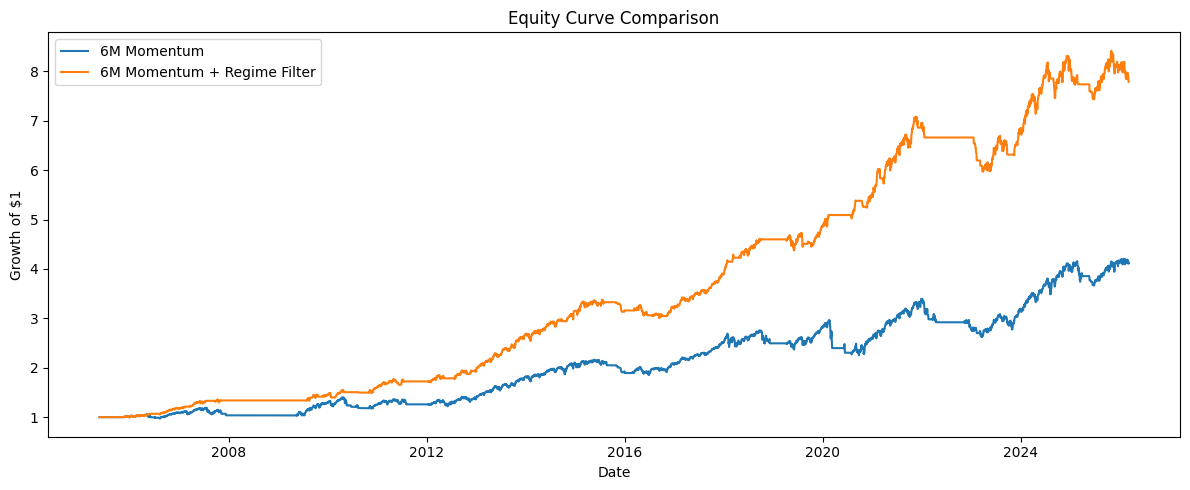

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(bt_momentum.index, bt_momentum["equity_curve"], label="6M Momentum")
plt.plot(bt_filtered.index, bt_filtered["equity_curve"], label="6M Momentum + Regime Filter")
plt.title("Equity Curve Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
exposure_summary = pd.Series({
    "momentum_exposure": bt_momentum["position"].mean(),
    "filtered_exposure": bt_filtered["position"].mean(),
})

exposure_summary

momentum_exposure    0.745792
filtered_exposure    0.565991
dtype: float64

In [13]:
pd.Series({
    "momentum_days_long": int(data["momentum_position"].sum()),
    "filtered_days_long": int(data["filtered_position"].sum()),
    "bull_calm_prob_above_threshold_days": int((data["bull_calm"] > CFG.regime_threshold).sum()),
})

momentum_days_long                     3899
filtered_days_long                     2959
bull_calm_prob_above_threshold_days    3230
dtype: int64

In [14]:
data["bull_calm_bucket"] = pd.cut(
    data["bull_calm"],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    include_lowest=True
)

data["next_day_return"] = data["Close"].pct_change().shift(-1)

bucket_summary = data.groupby("bull_calm_bucket")["next_day_return"].agg(["count", "mean", "std"])
bucket_summary

C:\Users\llr\AppData\Local\Temp\ipykernel_35820\1949929954.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_summary = data.groupby("bull_calm_bucket")["next_day_return"].agg(["count", "mean", "std"])


,count,mean,std
bull_calm_bucket,,,
"(-0.001, 0.3]",1818,0.000039,0.018020
"(0.3, 0.5]",142,-0.003081,0.011380
"(0.5, 0.7]",102,0.001050,0.009987
"(0.7, 1.0]",3165,0.000833,0.006594
